# Video Depth Anything Linear Alignment

Executed notebook for reproducing the GitHub-style linear depth alignment plot using the shared Drive Waymo ground truth and Video Depth Anything prediction stack.


In [1]:
import sys
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)
print(sorted(os.listdir('.'))[:12])

C:\Users\User\AppData\Local\Programs\Python\Python39\python.exe
['.git', '.gitignore', 'LICENSE', 'README.md', 'VideoDepthAnything_Heatmaps.ipynb', 'VideoDepthAnything_Linear_Alignment.ipynb', 'VideoDepthAnything_RMSE_Evaluation.ipynb', 'WAYMO_RMSE.md', '__pycache__', 'app.py', 'assets', 'benchmark']


In [2]:
from pathlib import Path

PRED_PATH = Path(r'G:\공유 드라이브\depth_estimators\VideoDepthAnything\video_depth_anything_depths.npy')
GT_ZIP_PATH = Path(r'G:\공유 드라이브\depth_estimators\waymo_open\output\depth.zip')
START_INDEX = 10
NUM_FRAMES = 5
MAX_DEPTH = 40.0
REQUIRE_POSITIVE_PRED = True

print('PRED_PATH:', PRED_PATH)
print('GT_ZIP_PATH:', GT_ZIP_PATH)
print('PRED exists:', PRED_PATH.exists())
print('GT zip exists:', GT_ZIP_PATH.exists())
print('Using frames:', START_INDEX, 'through', START_INDEX + NUM_FRAMES - 1)

PRED_PATH: G:\공유 드라이브\depth_estimators\VideoDepthAnything\video_depth_anything_depths.npy
GT_ZIP_PATH: G:\공유 드라이브\depth_estimators\waymo_open\output\depth.zip
PRED exists: True
GT zip exists: True
Using frames: 10 through 14


In [3]:
import io
import zipfile

pred = np.load(PRED_PATH, mmap_mode='r')
with zipfile.ZipFile(GT_ZIP_PATH) as zf:
    gt_frames = []
    for idx in range(START_INDEX, START_INDEX + NUM_FRAMES):
        with zf.open(f'depth/frame_{idx:05d}.npy') as f:
            gt_frames.append(np.load(io.BytesIO(f.read())).astype(np.float32))
gt = np.stack(gt_frames, axis=0)

pred_eval = []
for idx in range(START_INDEX, START_INDEX + NUM_FRAMES):
    frame = np.asarray(pred[idx], dtype=np.float32)
    frame = cv2.resize(frame, (gt.shape[2], gt.shape[1]), interpolation=cv2.INTER_LINEAR)
    pred_eval.append(frame)
pred_eval = np.stack(pred_eval, axis=0)

mask = np.isfinite(gt) & (gt > 0) & (gt <= MAX_DEPTH) & np.isfinite(pred_eval)
if REQUIRE_POSITIVE_PRED:
    mask &= pred_eval > 0

x = pred_eval[mask].astype(np.float64)
y = gt[mask].astype(np.float64)

print('prediction stack:', pred_eval.shape)
print('ground truth    :', gt.shape)
print('valid pixels    :', len(x))

prediction stack: (5, 1280, 1920)
ground truth    : (5, 1280, 1920)
valid pixels    : 90409


In [4]:
A = np.vstack([x, np.ones_like(x)]).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
print(f'Linear alignment: y = {slope:.4f}x + {intercept:.4f}')

Linear alignment: y = 40.0655x + -2.4431


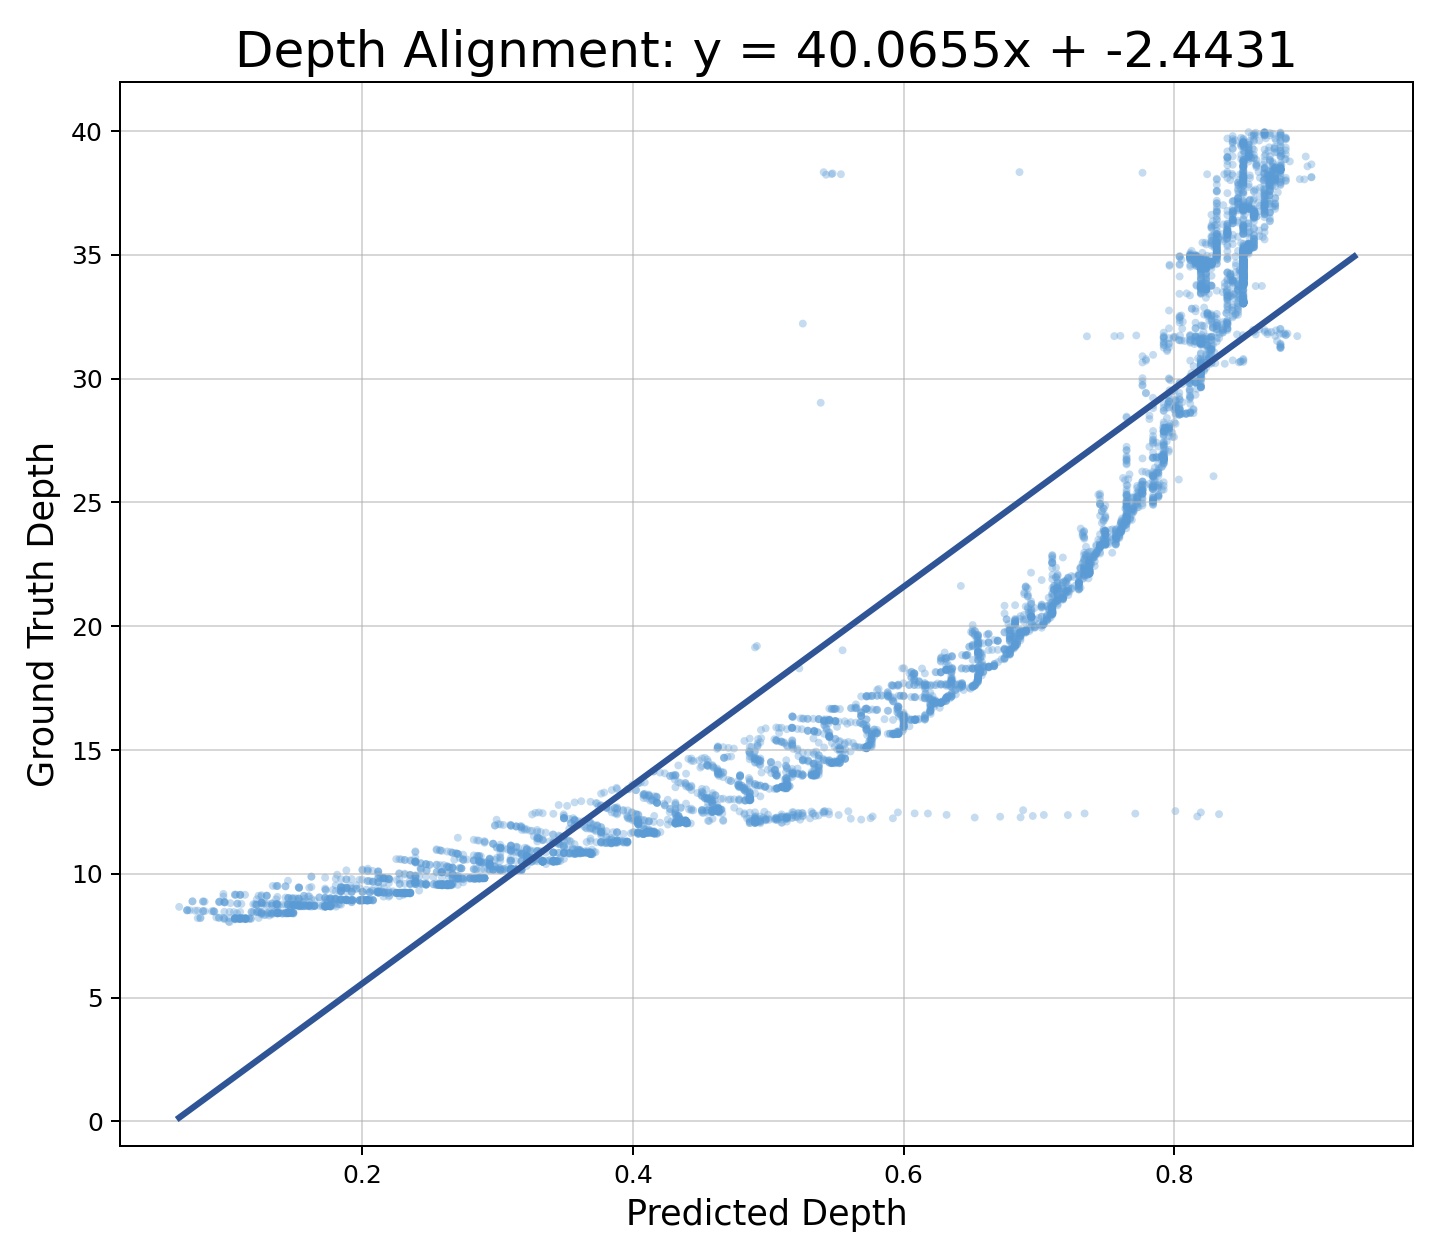

In [5]:
rng = np.random.default_rng(0)
PLOT_SAMPLE_SIZE = 6000
if len(x) > PLOT_SAMPLE_SIZE:
    sample_idx = rng.choice(len(x), PLOT_SAMPLE_SIZE, replace=False)
    x_plot = x[sample_idx]
    y_plot = y[sample_idx]
else:
    x_plot = x
    y_plot = y

x_line = np.linspace(float(x.min()), float(x.max()), 300)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 7))
plt.scatter(x_plot, y_plot, s=10, alpha=0.35, color='#5b9bd5', edgecolors='none')
plt.plot(x_line, y_line, color='#2f5597', linewidth=2.5)
plt.title(f'Depth Alignment: y = {slope:.4f}x + {intercept:.4f}', fontsize=20)
plt.xlabel('Predicted Depth', fontsize=14)
plt.ylabel('Ground Truth Depth', fontsize=14)
plt.ylim(-1, 42)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
